In [3]:
!pip install imbalanced-learn
!pip install xgboost


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 906.1 kB/s eta 0:01:17
   ---------------------------------------- 0.8/69.5 MB 875.8 kB/s eta 0:01:19
    --------------------------------------- 1.0/69.5 MB 977.2 kB/s eta 0:01:11
    --------------------------------------- 1.3/69.5 MB 1.0 MB/s eta 0:01:08
    --------------------------------------- 1.6/69.5 MB 1.0 MB/s eta 0:01:08
    --------------------------------------- 1.6/69.5 MB 1.0 MB/s eta 0:01:08
   - -------------------------------------- 1.8/69.5 MB 1.0 MB/s eta 0:01:07
   - -------------------------------------- 2.1/69.5 MB 1.0 MB/s eta 0:01:05
   - -------------------------------------- 2.4/69.5 MB 995.0 kB/s eta 0:01:08
   - --------------


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import pickle as pkl

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("clean_data.csv")

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96146 entries, 0 to 96145
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  int64  
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  int64  
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 6.6 MB


diabetes
0    87664
1     8482
Name: count, dtype: int64


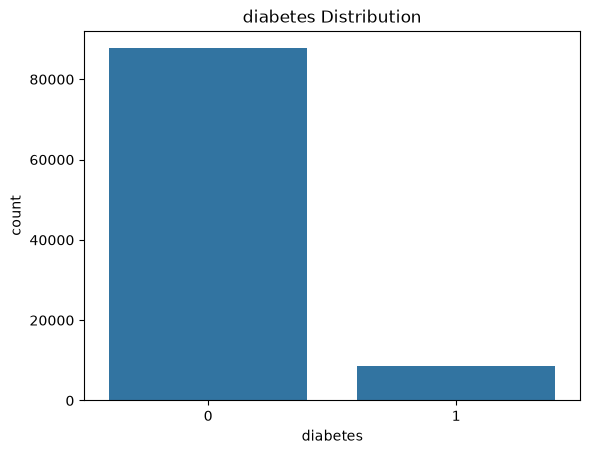

In [7]:
print(df["diabetes"].value_counts())

sns.countplot(x=df["diabetes"])
plt.title("diabetes Distribution")
plt.show()

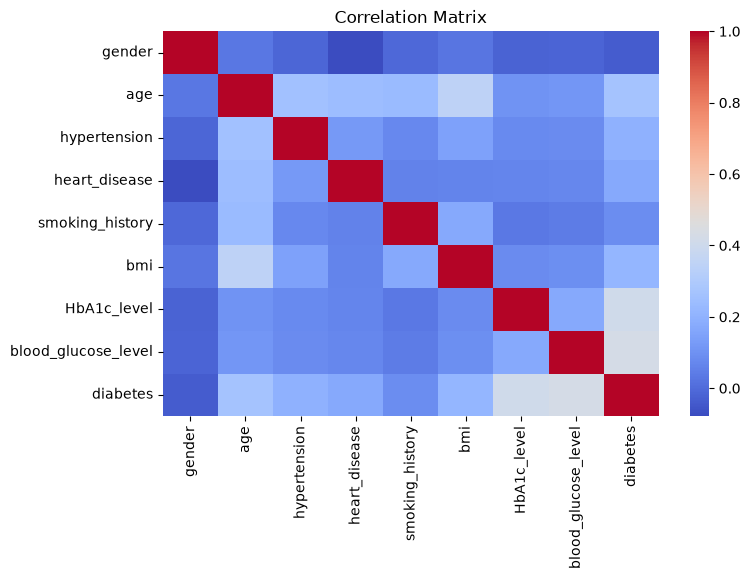

In [8]:
# To find correlations between all features
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [9]:
# Independent variables (features)
X = df.drop("diabetes", axis=1)

# Dependent variable (target)
y = df["diabetes"]

In [10]:
# Handling Imbalance using SMOTE
print("Before SMOTE:")
print(y.value_counts())

# SMOTE is used when one class has very less data than another
# It creates synthetic (fake but realistic) data for minority class
# SMOTE creates synthetic data for minority class

smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print(y.value_counts())

Before SMOTE:
diabetes
0    87664
1     8482
Name: count, dtype: int64

After SMOTE:
diabetes
0    87664
1    87664
Name: count, dtype: int64


In [11]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

In [12]:
# Preparing features based on category and numerical depending on semantics
categorical_features = [
    'gender',
    'hypertension',
    'heart_disease',
    'smoking_history'
]
numerical_features = [
    'age',
    'bmi',
    'HbA1c_level',
    'blood_glucose_level'
]

In [13]:
# Implementing the Column Transformer logic

# Numerical pipeline
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])

In [14]:
# Implementaion of Multi Model algorithms

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss")
}

In [15]:
# Hyperparameter Tuning

param_grids = {

    "Logistic Regression": {
        "model__C": np.logspace(-3, 3, 10)
    },

    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 6],
        "model__learning_rate": [0.01, 0.1]
    }
}

In [16]:
# Training Loop 

best_models = {}
best_accuracy = 0
best_model = None
best_model_name = ""

for name, model in models.items():

    print(f"\nTraining {name}...")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)    #=>  model = LogisticRegression(max_iter=1000)
    ])

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grids[name],
        n_iter=20,
        cv=3,
        verbose=1,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    predictions = search.predict(X_test)

    print(f"\n{name} Accuracy:", accuracy_score(y_test, predictions))
    print(classification_report(y_test, predictions))

    best_models[name] = search.best_estimator_
    
    y_pred = search.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = search.best_estimator_
        best_model_name = name


Training Logistic Regression...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Logistic Regression Accuracy: 0.9040380995836422
              precision    recall  f1-score   support

           0       0.91      0.90      0.90     17439
           1       0.90      0.91      0.90     17627

    accuracy                           0.90     35066
   macro avg       0.90      0.90      0.90     35066
weighted avg       0.90      0.90      0.90     35066


Training Random Forest...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Random Forest Accuracy: 0.9318428106998232
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     17439
           1       0.93      0.93      0.93     17627

    accuracy                           0.93     35066
   macro avg       0.93      0.93      0.93     35066
weighted avg       0.93      0.93      0.93     35066


Training XGBoost...
Fitting 3 folds for each of 8 candidates, totallin

In [19]:
# Export the best model based on Accuracy

import pickle

with open("best_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print(f"\n✅ Best Model Saved: {best_model_name}")
print(f"✅ Accuracy: {best_accuracy}")


✅ Best Model Saved: XGBoost
✅ Accuracy: 0.9740774539439914
